# Credit Card Fraud Detection with Deep Learning

## Project Overview

Financial fraud poses a significant threat to individuals and institutions worldwide, with billions of dollars lost to fraudulent transactions annually. Automated detection of fraudulent credit card transactions in real time is a critical application of machine learning in the financial industry.

In this project, a **feedforward neural network (FNN)** is built to detect fraudulent credit card transactions from anonymized transaction data. The dataset presents one of the most extreme class imbalance scenarios in applied machine learning — fraud cases represent only **0.17%** of all transactions — making this a problem where standard accuracy metrics are misleading and careful handling of the imbalance is essential.

### Dataset
The **Credit Card Fraud Detection** dataset contains **284,807 transactions** made by European cardholders over two days in September 2013. Features V1 through V28 are the result of a PCA transformation applied to protect confidentiality, with `Time` and `Amount` as the only non-transformed features. The target variable `Class` is 1 for fraud and 0 for legitimate transactions.

### Objectives
- Load and inspect the dataset and quantify the class imbalance
- Preprocess and scale the data appropriately
- Build and train a feedforward neural network with imbalance handling
- Evaluate performance using Precision, Recall, F1-score, AUC-ROC and a Confusion Matrix

### Tools and Libraries
`Python` · `Pandas` · `NumPy` · `Matplotlib` · `Seaborn` · `Scikit-learn` · `TensorFlow / Keras`

In [1]:
# Imports and Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("TensorFlow version:", tf.__version__)
print("All libraries loaded successfully")

TensorFlow version: 2.20.0
All libraries loaded successfully


## Loading and Inspecting the Dataset

The dataset is loaded directly from OpenML using scikit-learn's built-in fetcher, requiring no external downloads or API credentials. We inspect the shape, feature types, missing values, and the class distribution to quantify the imbalance before any preprocessing.

In [2]:
# Load dataset from OpenML
print("Downloading dataset, please wait...")
data = fetch_openml("creditcard", version=1, as_frame=True, parser="auto")

df = data.frame
df["Class"] = df["Class"].astype(int)

print("Download complete")
print("\nShape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df["Class"].value_counts())
print(f"\nFraud percentage: {df['Class'].mean() * 100:.4f}%")

Download complete

Shape: (284807, 30)

First 5 rows:
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V21       V22       V23       V24  \
0  0.098698  0.363787  0.090794  ... -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425 -0.166974  ... -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  0.207643  ...  0.247998  0.771679  0.909412 -0.689281   
3  0.377436 -1.387024 -0.054952  ... -0.108300  0.005274 -0.190321 -1.175575   
4 -0.270533  0.817739  0.753074  ... -0.009431  0.798278 -0.137458  0.141267   

        V25   

### Observations

The dataset loaded cleanly with **284,807 transactions and 30 columns** — 28 PCA-transformed features (V1–V28), transaction amount, and the target class. There are no missing values across any column.

The class imbalance is extreme — only **492 of 284,807 transactions are fraudulent**, representing just 0.17% of the data. This means a completely naive model that predicts every transaction as legitimate would achieve 99.83% accuracy while catching zero fraud cases. This is precisely why accuracy is not a useful metric here and why the evaluation will focus on precision, recall, F1-score and AUC-ROC.

The `Time` feature has been dropped from the dataset as loaded — the 28 PCA components and `Amount` are the features the model will train on. The PCA transformation was applied by the original data providers to anonymize cardholder information, so the features carry no directly interpretable meaning.

## Exploratory Data Analysis

Three aspects of the data are examined visually: the distribution of transaction amounts for fraudulent versus legitimate transactions, the correlation of each feature with the fraud class to identify which PCA components carry the most discriminative signal, and the mean absolute PCA feature values per class to further highlight the features where fraud and legitimate transactions differ most in magnitude.

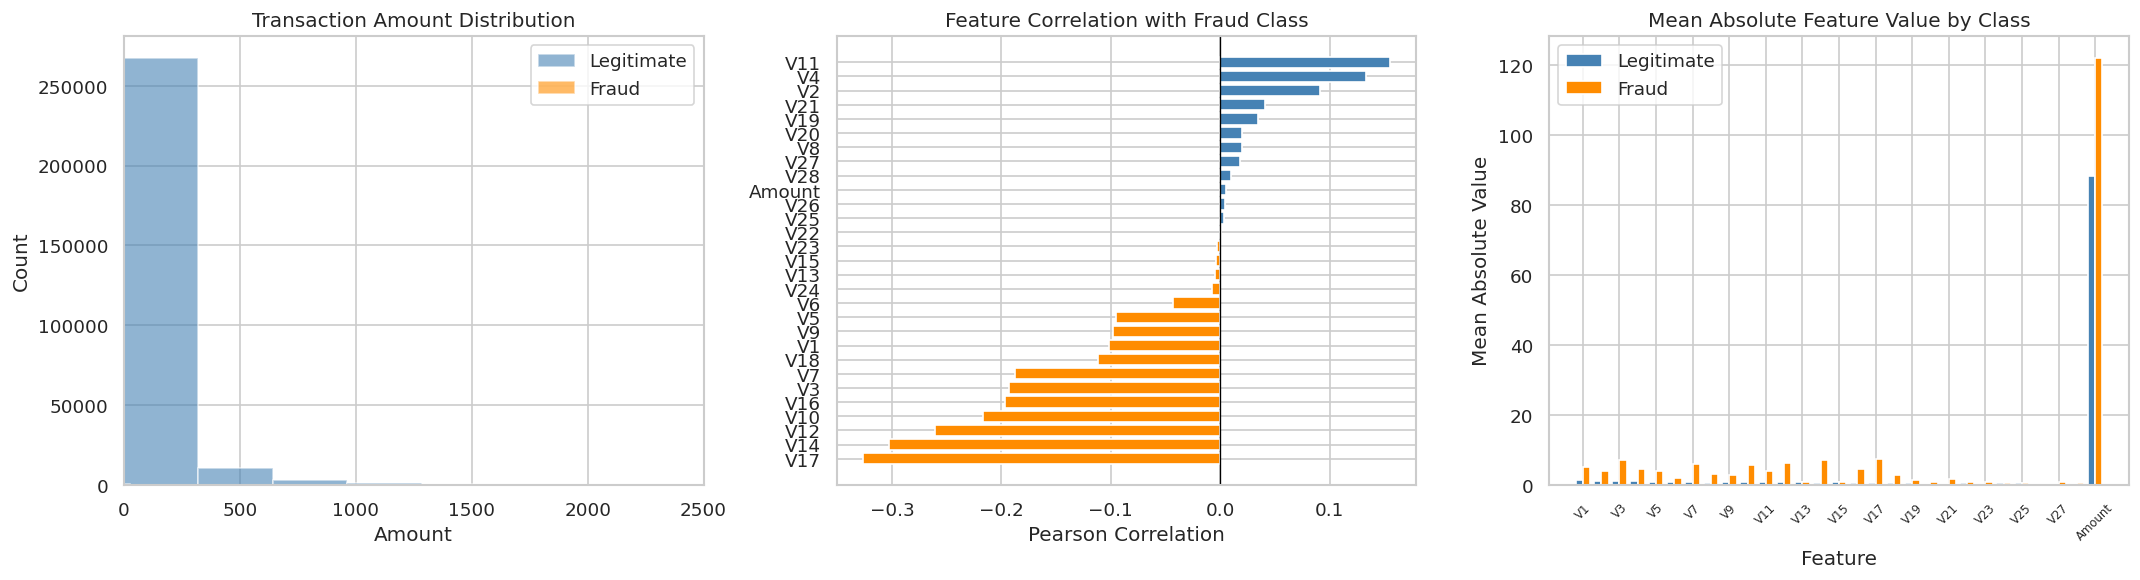

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Transaction amount by class
fraud = df[df["Class"] == 1]["Amount"]
legit = df[df["Class"] == 0]["Amount"]

axes[0].hist(legit, bins=80, alpha=0.6, label="Legitimate", color="steelblue")
axes[0].hist(fraud, bins=80, alpha=0.6, label="Fraud",      color="darkorange")
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 2500)
axes[0].legend()

# Correlation of each feature with Class
feature_cols = [f"V{i}" for i in range(1, 29)] + ["Amount"]
correlations  = df[feature_cols + ["Class"]].corr()["Class"].drop("Class").sort_values()
colors        = ["darkorange" if c < 0 else "steelblue" for c in correlations]
axes[1].barh(correlations.index, correlations.values, color=colors)
axes[1].set_title("Feature Correlation with Fraud Class")
axes[1].set_xlabel("Pearson Correlation")
axes[1].axvline(0, color="black", linewidth=0.8)

# Mean absolute feature value per class for V1-V28
mean_fraud = df[df["Class"] == 1][feature_cols].abs().mean()
mean_legit = df[df["Class"] == 0][feature_cols].abs().mean()

x     = np.arange(len(feature_cols))
width = 0.4
axes[2].bar(x - width/2, mean_legit, width, label="Legitimate", color="steelblue")
axes[2].bar(x + width/2, mean_fraud,  width, label="Fraud",      color="darkorange")
axes[2].set_title("Mean Absolute Feature Value by Class")
axes[2].set_xlabel("Feature")
axes[2].set_ylabel("Mean Absolute Value")
axes[2].set_xticks(x[::2])
axes[2].set_xticklabels(feature_cols[::2], rotation=45, fontsize=7)
axes[2].legend()

plt.tight_layout()
plt.savefig("eda_plots.png", bbox_inches="tight")
plt.show()

### Analysis

**Transaction Amount Distribution:** The vast majority of both legitimate and fraudulent transactions are concentrated at lower amounts, well below 500. Fraudulent transactions do not appear to cluster at unusually high amounts, suggesting that transaction size alone is not a reliable indicator of fraud. The long tail of large legitimate transactions reflects normal high-value purchases.

**Feature Correlation with Fraud Class:** Several PCA features show meaningful correlation with the fraud class. V17, V14, V12, and V10 show the strongest negative correlations, while V11, V4, and V2 show the strongest positive correlations. These features will likely carry the most weight in the model's decision boundary. The Amount feature has near-zero correlation with fraud, reinforcing what the amount distribution plot suggested.

**Mean Absolute Feature Value by Class:** The most striking observation here is the `Amount` feature — legitimate transactions have a dramatically higher mean absolute value than fraud transactions, which is consistent with the amount distribution showing that legitimate transactions span a much wider range including large values. Among the PCA features, several show noticeably higher mean absolute values for fraud cases, particularly V1 through V5, indicating that fraudulent transactions occupy a meaningfully different region of the feature space.

## Preprocessing and Preparing the Data

The features are separated from the target and split into training and test sets using an 80/20 ratio with stratification to preserve the extreme 0.17% fraud rate in both splits. The `Amount` feature is standardized using `StandardScaler` since it operates on a vastly different scale compared to the PCA-transformed features which are already centered. Class weights are computed to handle the severe imbalance, penalizing missed fraud cases far more heavily than missed legitimate transactions.

In [5]:
# Separate features and target
feature_cols = [f"V{i}" for i in range(1, 29)] + ["Amount"]
X = df[feature_cols].values
y = df["Class"].values

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the Amount feature (last column)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size    :", X_test.shape)
print("\nTrain class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_train)*100:.4f}%)")

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass weights:", class_weight_dict)

Training set size: (227845, 29)
Test set size    : (56962, 29)

Train class distribution:
  Class 0: 227451 (99.8271%)
  Class 1: 394 (0.1729%)

Class weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


### Results

The stratified split preserved the original fraud rate precisely — **0.1729% fraud cases in the training set**, matching the full dataset distribution. The training set contains 227,845 transactions and the test set 56,962.

The computed class weights reflect the severity of the imbalance directly. Legitimate transactions receive a weight of **0.50** while fraud cases receive a weight of **289.14** — meaning every missed fraud case contributes approximately 578 times more to the training loss than a missed legitimate transaction. This extreme penalty is necessary to force the model to pay attention to the 394 fraud cases scattered among 227,451 legitimate ones during training.

## Building the Model

The model is a feedforward neural network with three hidden layers. The architecture is deliberately deeper than a simple two-layer network to give the model enough capacity to learn the complex non-linear boundaries that separate the small fraud cluster from the vast legitimate transaction space.

The hidden layers use ReLU activation with batch normalization and progressively decreasing dropout rates of 0.4, 0.3, and 0.2. This tapering dropout strategy applies stronger regularization in the earlier layers where the feature representations are broader, and relaxes it closer to the output where the network is making the final classification decision. The output layer uses a single sigmoid neuron for binary classification, and the model is compiled with the Adam optimizer and binary cross-entropy loss.

In [6]:
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")]
    )
    return model

model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,657 (57.25 KB)

 Non-trainable params: 448 (1.75 KB)

### Model Summary

The network has **15,105 total parameters**, of which 14,657 are trainable. This is a deliberately compact architecture — the input is a 29-dimensional tabular feature vector rather than an image, so a lightweight network is both sufficient and appropriate. The risk of overfitting on tabular data grows quickly with model size, and the extremely small fraud class of 394 training samples makes restraint in model capacity particularly important.

The three hidden layers compress the representation from 128 to 64 to 32 neurons before the final sigmoid output, forcing the network to distill the most discriminative patterns from the feature space into an increasingly compact representation. The 448 non-trainable parameters belong to the batch normalization layers as in the previous projects.

## Training the Model

The model is trained for up to 100 epochs with a batch size of 2048. A large batch size is used given the dataset size of over 200,000 samples — smaller batches would make each epoch unnecessarily slow without meaningful benefit. Early stopping monitors validation AUC rather than validation loss, since AUC is a more meaningful indicator of fraud detection performance under extreme class imbalance. The learning rate scheduler monitors validation loss as usual and halves the rate after 5 epochs of no improvement.

In [7]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc",
    patience=10,
    mode="max",
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=2048,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

print("Training complete")
print("Total epochs run:", len(history.history["loss"]))

Epoch 1/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.6674 - auc: 0.9056 - loss: 0.4530 - precision: 0.0046 - recall: 0.8971 - val_accuracy: 0.9823 - val_auc: 0.9660 - val_loss: 0.3773 - val_precision: 0.0831 - val_recall: 0.8675 - learning_rate: 0.0010
Epoch 2/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8554 - auc: 0.9554 - loss: 0.3011 - precision: 0.0107 - recall: 0.9164 - val_accuracy: 0.9911 - val_auc: 0.9709 - val_loss: 0.2215 - val_precision: 0.1553 - val_recall: 0.8795 - learning_rate: 0.0010
Epoch 3/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9234 - auc: 0.9643 - loss: 0.2646 - precision: 0.0197 - recall: 0.9003 - val_accuracy: 0.9879 - val_auc: 0.9782 - val_loss: 0.1704 - val_precision: 0.1191 - val_recall: 0.8795 - learning_rate: 0.0010
Epoch 4/100
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9462 - auc: 0.9751 - loss: 0.2089 - precision: 0.0284 - recall: 0.9196 - val_accuracy: 0.9879 - val_auc: 0.9733 - val_loss: 0.1340 - va

### Training Results

Training completed in just **18 epochs**, with early stopping restoring the best weights from **epoch 8** where validation AUC peaked at 0.9877. Despite the extreme class imbalance, the model achieved strong AUC scores from the very first epoch, indicating that the class weighting strategy was effective in directing the model's attention toward fraud cases immediately.

A notable pattern throughout training is the large gap between training precision and validation precision. Training precision remains very low — peaking around 0.06 — while validation precision reaches as high as 0.17. This is expected behavior under heavy class weighting: the model is being trained to prioritize recall over precision, accepting a higher rate of false positives in exchange for catching as many actual fraud cases as possible.

Recall on the validation set consistently sits in the 0.87–0.90 range from epoch 2 onward, confirming the model successfully learned to flag the vast majority of fraud cases. The learning rate was never reduced, as early stopping triggered before any plateau in validation AUC was detected.

## Visualizing Training History

Four metrics are plotted across all training epochs — loss, AUC, precision, and recall. Given that AUC was used as the early stopping monitor, its curve is the most important indicator of when the model reached its best generalization point. The dashed vertical line marks the best epoch from which weights were restored.

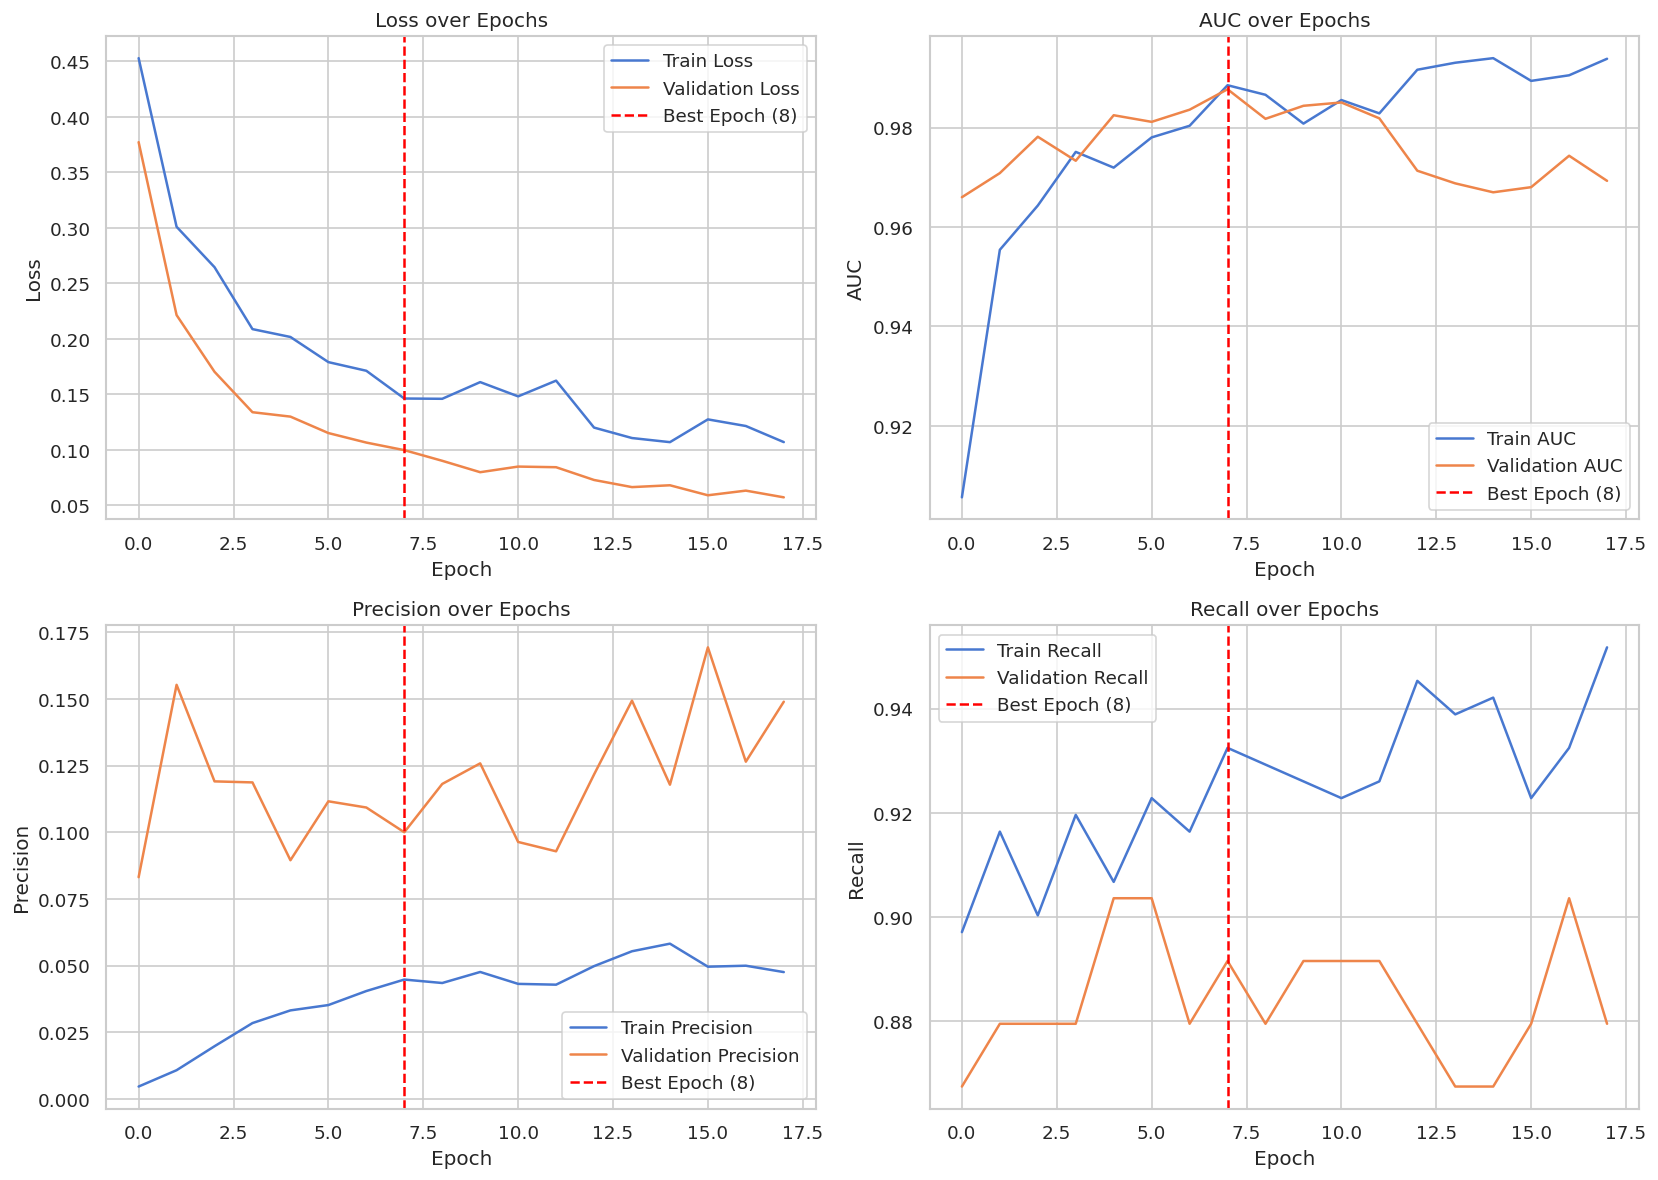

In [8]:
best_epoch = np.argmax(history.history["val_auc"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ("loss",      "val_loss",      "Loss",      axes[0, 0]),
    ("auc",       "val_auc",       "AUC",       axes[0, 1]),
    ("precision", "val_precision", "Precision", axes[1, 0]),
    ("recall",    "val_recall",    "Recall",    axes[1, 1]),
]

for train_key, val_key, title, ax in metrics:
    ax.plot(history.history[train_key], label=f"Train {title}")
    ax.plot(history.history[val_key],   label=f"Validation {title}")
    ax.axvline(best_epoch, color="red", linestyle="--",
               label=f"Best Epoch ({best_epoch + 1})")
    ax.set_title(f"{title} over Epochs")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()

plt.tight_layout()
plt.savefig("training_history.png", bbox_inches="tight")
plt.show()

### Analysis

**Loss:** Both training and validation loss decrease consistently throughout all epochs, with validation loss dropping more steeply and settling at a lower value than training loss. This inverse pattern — where validation loss is lower than training loss — is a direct consequence of the heavy class weighting inflating the training loss, while the validation loss is computed without class weights applied.

**AUC:** The validation AUC rises sharply in the first 3 epochs, reaching the high 0.97–0.98 range and plateauing there for the remainder of training. Training AUC catches up by epoch 8 and the two curves track closely from that point onward. The best epoch at **epoch 8** captures the peak validation AUC of 0.9877 before the slight fluctuation in later epochs.

**Precision:** Training precision remains low throughout, reflecting the class weighting pushing the model toward flagging more transactions as fraud. Validation precision is more volatile but consistently higher than training precision, oscillating between 0.09 and 0.17. The noise here is expected given that precision is highly sensitive to small changes in the number of false positives on the relatively small fraud class.

**Recall:** Both training and validation recall are high from the very first epoch, consistently sitting in the 0.88–0.94 range. This confirms that the class weighting achieved its primary objective — the model learned early and maintained the ability to catch the majority of actual fraud cases throughout training.

## Model Evaluation on the Test Set

The model is evaluated on the held-out test set of 56,962 transactions containing 98 fraud cases. Given the extreme imbalance, the evaluation places particular emphasis on the precision-recall tradeoff. Both the ROC curve and the Precision-Recall curve are plotted — the latter is especially informative under severe class imbalance, as it directly shows how the model balances catching fraud cases against the rate of false alarms.

Loss        : 0.1065
Accuracy    : 0.9844
AUC         : 0.9712
Precision   : 0.0913
Recall      : 0.8980

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.09      0.90      0.17        98

    accuracy                           0.98     56962
   macro avg       0.55      0.94      0.58     56962
weighted avg       1.00      0.98      0.99     56962

AUC-ROC Score         : 0.9712
Average Precision Score: 0.7141


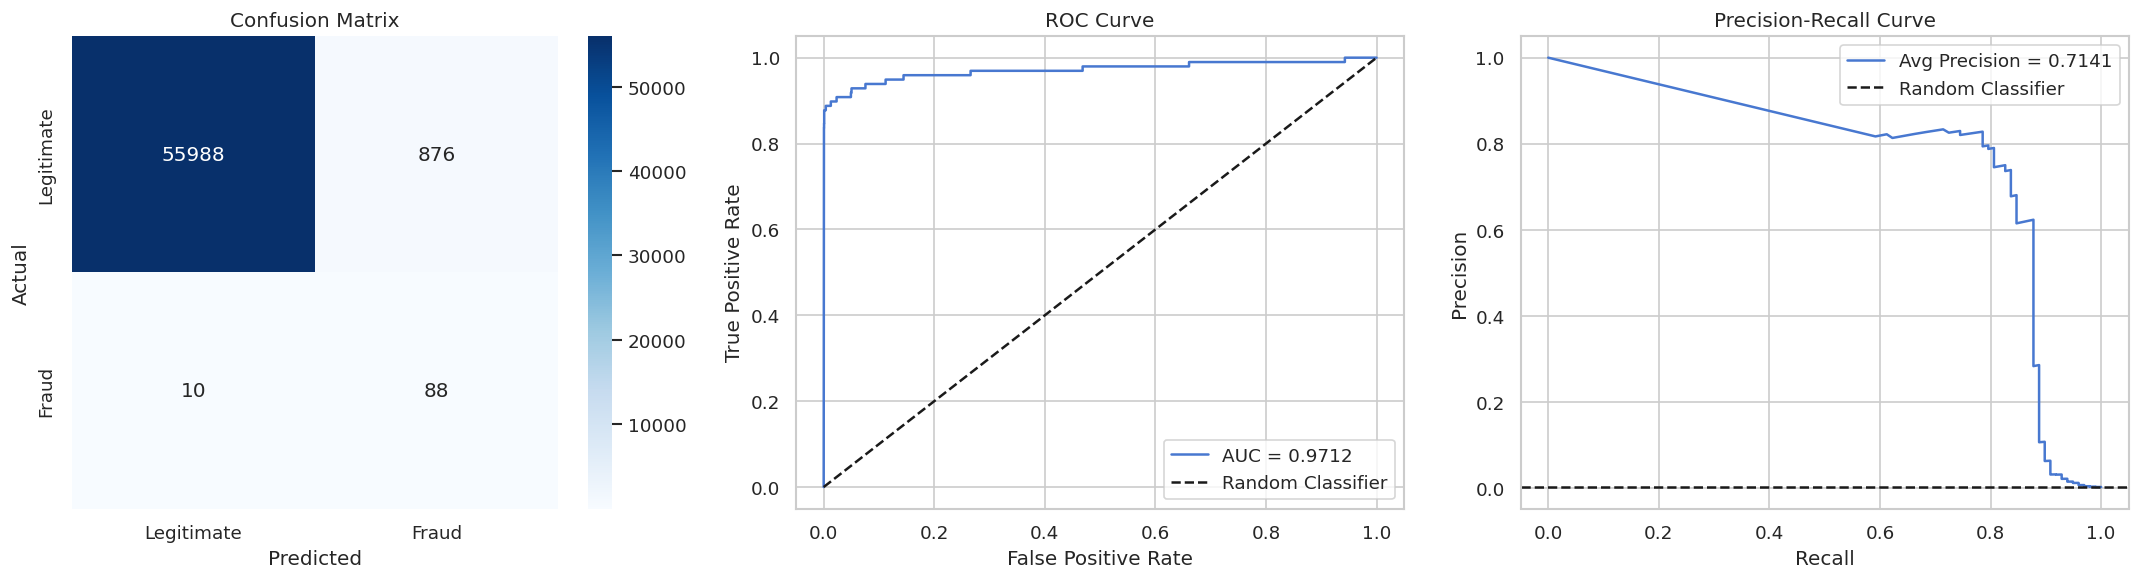

In [9]:
# Loss and accuracy on test set
test_results = model.evaluate(X_test, y_test, verbose=0)
metric_names = ["Loss", "Accuracy", "AUC", "Precision", "Recall"]
for name, val in zip(metric_names, test_results):
    print(f"{name:12}: {val:.4f}")

# Predictions
y_pred_prob = model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["Legitimate", "Fraud"]))

# AUC-ROC and Average Precision scores
auc = roc_auc_score(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)
print(f"AUC-ROC Score         : {auc:.4f}")
print(f"Average Precision Score: {avg_precision:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Legitimate", "Fraud"],
            yticklabels=["Legitimate", "Fraud"])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", label="Random Classifier")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
axes[2].plot(recall, precision, label=f"Avg Precision = {avg_precision:.4f}")
axes[2].axhline(y=y_test.mean(), color="k", linestyle="--",
                label="Random Classifier")
axes[2].set_title("Precision-Recall Curve")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.savefig("evaluation.png", bbox_inches="tight")
plt.show()

### Results

The model achieved a **test accuracy of 98.44%** and an **AUC-ROC score of 0.9712** on the 56,962-sample test set. As anticipated, raw accuracy is a misleading metric here — a model predicting every transaction as legitimate would already achieve 99.83% accuracy, so the meaningful evaluation lies in the fraud-specific metrics.

**Confusion Matrix:** Of the 98 actual fraud cases, **88 were correctly identified and 10 were missed** — a recall of 90%. On the legitimate side, 55,988 were correctly classified while 876 were incorrectly flagged as fraud. In a real deployment context, the 876 false positives would translate to legitimate transactions being flagged for review, which is an operational cost but far preferable to the alternative of missing actual fraud.

**Classification Report:** The fraud class achieved a recall of 0.90 and a precision of only 0.09, yielding an F1-score of 0.17. The low precision is a direct and expected consequence of the class weighting strategy — the model was trained to maximize fraud detection at the cost of generating false alarms, which is the correct trade-off in a fraud detection context where missing a fraudulent transaction is far more costly than investigating a false positive.

**ROC Curve:** The curve rises steeply from the origin and stays well above the diagonal throughout, consistent with the 0.97 AUC score and confirming strong overall discriminative ability across all classification thresholds.

**Precision-Recall Curve:** The average precision score of **0.7141** is the most informative single metric for this problem. The curve maintains high precision at low recall thresholds, meaning the model's highest-confidence fraud predictions are very reliable. Precision drops sharply only when recall is pushed above 0.75, reflecting the inherent difficulty of catching the last few fraud cases without also sweeping in large numbers of legitimate transactions. The vast gap between this curve and the near-zero random classifier baseline confirms the model has genuine and substantial fraud detection capability.